In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [ ]:
processed_path = r"processed_data"

In [ ]:


violence_path = os.path.join(processed_path, "V")
nonviolence_path = os.path.join(processed_path, "NV")

In [ ]:
from collections import defaultdict

video_frames = defaultdict(list)

for frame in os.listdir(violence_path):
    video_id = "_".join(frame.split("_")[1:3])
    video_frames[video_id].append(os.path.join(violence_path, frame))

for frame in os.listdir(nonviolence_path):
    video_id = "_".join(frame.split("_")[1:3]
                        )
    video_frames[video_id].append(os.path.join(nonviolence_path, frame))

print("Total videos:", len(video_frames))

Total videos: 2000


In [5]:
video_ids = list(video_frames.keys())

print("Example video IDs:", video_ids[:10])
print("Total videos:", len(video_ids))

Example video IDs: ['V_1000', 'V_100', 'V_101', 'V_102', 'V_103', 'V_104', 'V_105', 'V_106', 'V_107', 'V_108']
Total videos: 2000


In [6]:
labels = []

for vid in video_ids:
    if vid.startswith("V"):
        labels.append(1)
    else:
        labels.append(0)

print("Example labels:", labels[:10])

Example labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [7]:
from sklearn.model_selection import train_test_split

train_ids, test_ids, train_labels, test_labels = train_test_split(
    video_ids,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train videos:", len(train_ids))
print("Test videos:", len(test_ids))

Train videos: 1600
Test videos: 400


In [8]:
import cv2
import numpy as np
import tensorflow as tf

class VideoGenerator(tf.keras.utils.Sequence):

    def __init__(self, video_ids, labels, video_frames, batch_size=4):
        self.video_ids = video_ids
        self.labels = labels
        self.video_frames = video_frames
        self.batch_size = batch_size

    def __len__(self):
        return len(self.video_ids) // self.batch_size

    def __getitem__(self, idx):

        batch_ids = self.video_ids[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X = []
        y = []

        for vid, label in zip(batch_ids, batch_labels):

            frames = sorted(self.video_frames[vid])

            sequence = []

            for frame in frames:
                img = cv2.imread(frame)
                img = cv2.resize(img,(160,160))
                img = img / 255.0
                sequence.append(img)

            X.append(sequence)
            y.append(label)

        return np.array(X), np.array(y)

In [9]:
train_gen = VideoGenerator(train_ids, train_labels, video_frames, batch_size=4)
test_gen = VideoGenerator(test_ids, test_labels, video_frames, batch_size=4)

In [10]:
X, y = train_gen[0]
print(X.shape, y.shape)

(4, 16, 160, 160, 3) (4,)


In [11]:
#MODEL BUILDING

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

# CNN feature extractor (applied to each frame)
model.add(TimeDistributed(
    Conv2D(32, (3,3), activation='relu'),
    input_shape=(16,160,160,3)
))
model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(Conv2D(64,(3,3),activation='relu')))
model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(Conv2D(128,(3,3),activation='relu')))
model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(Flatten()))

# Temporal learning
model.add(LSTM(64))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  (None, 16, 158, 158, 32)  896      
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  (None, 16, 79, 79, 32)   0         
 tributed)                                                       
                                                                 
 time_distributed_2 (TimeDis  (None, 16, 77, 77, 64)   18496     
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  (None, 16, 38, 38, 64)   0         
 tributed)                                                       
                                                                 
 time_distributed_4 (TimeDis  (None, 16, 36, 36, 128)  7

In [13]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=50
)

Epoch 1/50
400/400 [==============================] - 111s 202ms/step - loss: 0.6611 - accuracy: 0.5881 - val_loss: 0.5107 - val_accuracy: 0.7900
Epoch 2/50
400/400 [==============================] - 52s 129ms/step - loss: 0.4971 - accuracy: 0.7688 - val_loss: 0.5171 - val_accuracy: 0.7450
Epoch 3/50
400/400 [==============================] - 53s 132ms/step - loss: 0.3871 - accuracy: 0.8419 - val_loss: 0.3183 - val_accuracy: 0.8650
Epoch 4/50
400/400 [==============================] - 67s 168ms/step - loss: 0.2674 - accuracy: 0.8988 - val_loss: 0.2955 - val_accuracy: 0.8725
Epoch 5/50
400/400 [==============================] - 47s 119ms/step - loss: 0.2112 - accuracy: 0.9212 - val_loss: 0.2323 - val_accuracy: 0.9050
Epoch 6/50
400/400 [==============================] - 48s 119ms/step - loss: 0.1734 - accuracy: 0.9406 - val_loss: 0.2282 - val_accuracy: 0.9250
Epoch 7/50
400/400 [==============================] - 48s 119ms/step - loss: 0.1228 - accuracy: 0.9600 - val_loss: 0.2200 - val_a

In [14]:
model.save("violence_detection_model.h5")

In [1]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Violence-detection\models\violence_detection_model.h5")

print("Model loaded successfully")

Model loaded successfully


In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

In [2]:
import os
os.chdir("D:/Violence_detection")
print(os.getcwd())

D:\Violence_detection


In [3]:
model = load_model(r"violence_detection_model.h5")

print("Model loaded successfully")

Model loaded successfully


In [4]:
import cv2
import numpy as np
from collections import deque

def detect_violence_in_video(video_path):

    cap = cv2.VideoCapture(video_path)

    frame_buffer = deque(maxlen=32)
    prediction_buffer = deque(maxlen=10)

    label = "Initializing..."
    color = (255,255,0)

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        display = frame.copy()

        # preprocess frame
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (160,160))
        img = img / 255.0

        frame_buffer.append(img)

        if len(frame_buffer) == 32:

            # uniform sampling
            idx = np.linspace(0,31,16).astype(int)
            sampled = [frame_buffer[i] for i in idx]

            input_frames = np.expand_dims(sampled, axis=0)

            prediction = model.predict(input_frames, verbose=0)[0][0]

            prediction_buffer.append(prediction)

            # smooth prediction
            avg_pred = np.mean(prediction_buffer)

            if avg_pred > 0.7:
                label = "VIOLENCE"
                color = (0,0,255)
            else:
                label = "NON-VIOLENCE"
                color = (0,255,0)

        cv2.putText(display, label, (20,40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        cv2.imshow("Violence Detection", display)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [5]:
video_path = r"dataset\Real Life Violence Dataset\Violence\V_1201.mp4"

detect_violence_in_video(video_path)

In [6]:
import cv2
import numpy as np

def webcam_violence_detection():

    cap = cv2.VideoCapture(0)

    frame_buffer = []
    pred_buffer = []

    label = "SAFE"
    color = (0,255,0)

    prev_gray = None

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        display = frame.copy()

        # -------- Motion Detection --------
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        motion_level = 0

        if prev_gray is not None:
            diff = cv2.absdiff(prev_gray, gray)
            motion_level = np.mean(diff)

        prev_gray = gray

        # If motion is very small → SAFE
        if motion_level < 2.5:
            label = "SAFE"
            color = (0,255,0)

        else:

            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img,(160,160))
            img = img / 255.0

            frame_buffer.append(img)

            if len(frame_buffer) > 16:
                frame_buffer.pop(0)

            if len(frame_buffer) == 16:

                input_frames = np.expand_dims(frame_buffer, axis=0)

                prediction = model.predict(input_frames, verbose=0)[0][0]

                pred_buffer.append(prediction)

                if len(pred_buffer) > 5:
                    pred_buffer.pop(0)

                avg_pred = np.mean(pred_buffer)

                print("Prediction:", avg_pred)

                if avg_pred > 0.2:
                    label = "VIOLENCE"
                    color = (0,0,255)
                else:
                    label = "SAFE"
                    color = (0,255,0)

        cv2.putText(display,label,(20,40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,color,2)

        cv2.imshow("Webcam Violence Detection",display)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [7]:
webcam_violence_detection()

Prediction: 0.9703569
Prediction: 0.98471653
Prediction: 0.989791
Prediction: 0.99233884
Prediction: 0.9938674
Prediction: 0.99979097
Prediction: 0.99996996
Prediction: 0.9999754
Prediction: 0.9999717
Prediction: 0.99996835
Prediction: 0.9999677
Prediction: 0.99996835
Prediction: 0.99996966
Prediction: 0.99997294
Prediction: 0.9999773
Prediction: 0.9999812
Prediction: 0.99998456
Prediction: 0.9999882
Prediction: 0.9999903
Prediction: 0.99999106
Prediction: 0.9999908
Prediction: 0.99998885
Prediction: 0.99998647
Prediction: 0.99998444
Prediction: 0.99998254
Prediction: 0.99998045
Prediction: 0.9999796
Prediction: 0.999975
Prediction: 0.99990475
Prediction: 0.9994486
Prediction: 0.9993556
Prediction: 0.9993437
Prediction: 0.9993354
Prediction: 0.999383
Prediction: 0.9997581
Prediction: 0.9965914
Prediction: 0.7997305
Prediction: 0.5999046
Prediction: 0.4000001
Prediction: 0.20016165
Prediction: 0.0035008998
Prediction: 0.00073591515
Prediction: 0.0013407313
Prediction: 0.0019377101
Predi

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_video_16_frames(video_path):

    cap = cv2.VideoCapture(video_path)

    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    cap.release()

    total_frames = len(frames)

    # uniformly sample 16 frames across video
    indices = np.linspace(0, total_frames - 1, 16).astype(int)
    sampled_frames = [frames[i] for i in indices]

    processed_frames = []

    for frame in sampled_frames:
        img = cv2.resize(frame, (160,160))
        img = img / 255.0
        processed_frames.append(img)

    input_frames = np.expand_dims(processed_frames, axis=0)

    prediction = model.predict(input_frames, verbose=0)[0][0]

    if prediction > 0.5:
        label = "VIOLENCE"
        color = "red"
    else:
        label = "NON-VIOLENCE"
        color = "green"

    # show frames in notebook
    plt.figure(figsize=(15,6))

    for i, frame in enumerate(sampled_frames):
        plt.subplot(2,8,i+1)
        plt.imshow(frame)
        plt.axis("off")

    plt.suptitle(f"Prediction: {label}  (score={prediction:.2f})",
                 fontsize=16, color=color)

    plt.show()

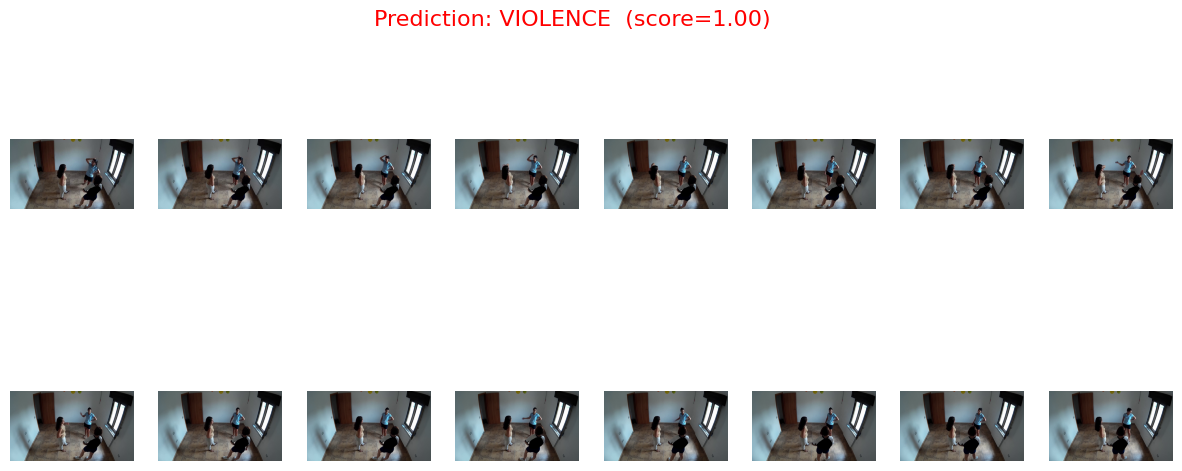

In [12]:
video_path = r"dataset\Real Life Violence Dataset\NonViolence\NV_1117.mp4"

predict_video_16_frames(video_path)